# Semantic Shard Prototype - Step 3 (Community Detection)

This notebook tests the full non-GNN prototype:
- Step 1 semantic shards
- Step 2 weighted shard graph
- Step 3 weighted community detection to produce final email-level grouping

Goal:
- improve completeness over RAW baseline
- keep homogeneity high enough to remain competitive

Out of scope in this step:
- GNN on shard graph
- any end-to-end neural training


## Fast run order

Run these first:
1. load artifacts and sanity checks
2. community sweep results table
3. baseline comparison table
4. fragmentation before vs after table/plots
5. merge outcomes on RAW-fragmented campaigns
6. final summary


In [5]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_here = Path.cwd().resolve()
PROJECT_ROOT = _here if (_here / "pipeline_config.json").is_file() else _here.parent
assert (PROJECT_ROOT / "pipeline_config.json").is_file(), f"Set cwd to repo root or analysis/; got {PROJECT_ROOT}"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.utils import raw_gnn_notebook as rn
from analysis.utils import semantic_shard_graph_helpers as s2
from analysis.utils import semantic_shard_step3_helpers as s3

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)


In [6]:
# -------- Controls --------
RUN_ID = "vicreg_pruned_graph_email_zero_edge_drop_v3_aggressive"

STEP1_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step1"
# Step-2 graph: default vs routing-inclusive build (see Step-2 INCLUDE_ROUTING_CHANNELS_IN_GRAPH + output dir)
STEP2_BASE_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step2_graph"  # old/default path kept for quick fallback
STEP2_ROUTING_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step2_graph_routing"
USE_STEP2_ROUTING_GRAPH = False  # True -> semantic_shard_step2_graph_routing + semantic_shard_step3_routing
STEP2_DIR = STEP2_ROUTING_DIR if USE_STEP2_ROUTING_GRAPH else STEP2_BASE_DIR
STEP3_OUT_DIR = (
    PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step3_routing"
    if USE_STEP2_ROUTING_GRAPH
    else PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step3"
)

STEP1_ASSIGNMENTS_CSV = STEP1_DIR / "semantic_shard_step1_assignments.csv"

RAW_SWEEP_CSV = PROJECT_ROOT / "core" / "GNN" / "outputs" / RUN_ID / "clustering" / "hdbscan" / "raw_email_embeddings_hdbscan_sweep.csv"
TRANSFORMER_SWEEP_CSV = PROJECT_ROOT / "core" / "GNN" / "outputs" / RUN_ID / "clustering" / "hdbscan" / "transformer_text_embeddings_hdbscan_sweep.csv"

GRAPH_PT = PROJECT_ROOT / "core" / "graph" / "output" / "incidents-lake-misp-large_hetero.pt"
GRAPH_META = GRAPH_PT.with_suffix(".meta.json")

# Use normal GT by default (as requested), plus optional dedup comparison.
GT_PATH = PROJECT_ROOT / "data" / "groundtruth" / "ground_truth_merged.json"
GT_DEDUP_PATH = PROJECT_ROOT / "data" / "groundtruth" / "ground_truth_dedup.json"
PRIMARY_EVAL_GT = GT_PATH  # change to GT_DEDUP_PATH if desired
TO_UNDIRECTED = True

# Method 1 (optional): run analysis/semantic_shard_prototype_step2b_method1_edge_refine.ipynb first
METHOD1_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_method1"
USE_METHOD1_REFINED_EDGES = False
COMMUNITY_WEIGHT_COL = "edge_weight_refined" if USE_METHOD1_REFINED_EDGES else "edge_weight"

# Community detection: "louvain" | "greedy" | "leiden" (install python-igraph + leidenalg for Leiden)
COMMUNITY_METHOD = "louvain"
RANDOM_SEED = 0
RESOLUTION_VALUES = [0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3]
MIN_EDGE_WEIGHT_VALUES = [0.00, 0.25, 0.50]

# Optional: compare multiple Step-2 graph settings side-by-side.
# Each entry should point at a Step-2 output directory that includes
#   semantic_shard_step2_graph_summary.json
# and should include the community detection resolution/min_edge_weight to evaluate.
STEP2_EXPERIMENTS = []
# Example:
# STEP2_EXPERIMENTS = [
#     {"key": "s2_default", "step2_dir": str(STEP2_DIR), "resolution": 1.0, "min_edge_weight": 0.15},
#     {"key": "s2_more_channels", "step2_dir": str(STEP2_DIR2), "resolution": 1.0, "min_edge_weight": 0.15},
# ]


## 1) Load Step-1 + Step-2 artifacts

What this section confirms:
- shard assignment coverage from Step 1
- weighted shard graph size from Step 2
- edge-weight distribution sanity
- this notebook operates on shard graph artifacts (not the old hetero graph structure)


In [7]:
assignments_df = s2.load_step1_assignments(STEP1_ASSIGNMENTS_CSV)
shard_nodes_df, edges_df_baseline, candidates_df = s3.load_step2_artifacts(STEP2_DIR)

if USE_METHOD1_REFINED_EDGES:
    edges_df = s3.load_method1_refined_edges(METHOD1_DIR)
    if COMMUNITY_WEIGHT_COL not in edges_df.columns:
        raise KeyError(
            f"Column {COMMUNITY_WEIGHT_COL!r} not in refined edges; check Step 2b output."
        )
else:
    edges_df = edges_df_baseline

print("Step-1 assignments:", STEP1_ASSIGNMENTS_CSV)
print("Step-2 dir:", STEP2_DIR)
print("Edge table:", "Method 1 refined" if USE_METHOD1_REFINED_EDGES else "Step-2 baseline")
print("CD weight column:", COMMUNITY_WEIGHT_COL)
print("n_shards:", shard_nodes_df["shard_id"].nunique())
print("n_emails_assigned:", len(assignments_df))
print("n_weighted_edges:", len(edges_df))
print("n_candidate_edges:", len(candidates_df))

wcol = COMMUNITY_WEIGHT_COL if COMMUNITY_WEIGHT_COL in edges_df.columns else "edge_weight"
stat_cols = ["edge_weight"] if wcol == "edge_weight" else [wcol, "edge_weight"]
rows = []
for c in stat_cols:
    if c not in edges_df.columns:
        continue
    rows.extend(
        [
            {"metric": f"{c}_min", "value": float(edges_df[c].min()) if not edges_df.empty else np.nan},
            {"metric": f"{c}_mean", "value": float(edges_df[c].mean()) if not edges_df.empty else np.nan},
            {"metric": f"{c}_median", "value": float(edges_df[c].median()) if not edges_df.empty else np.nan},
            {"metric": f"{c}_max", "value": float(edges_df[c].max()) if not edges_df.empty else np.nan},
        ]
    )
diag_df = pd.DataFrame(rows)
display(diag_df)


Step-1 assignments: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step1\semantic_shard_step1_assignments.csv
Step-2 dir: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step2_graph
Edge table: Step-2 baseline
CD weight column: edge_weight
n_shards: 2895
n_emails_assigned: 7333
n_weighted_edges: 4390
n_candidate_edges: 4390


,metric,value
0,edge_weight_min,0.527509
1,edge_weight_mean,1.003123
2,edge_weight_median,1.100477
3,edge_weight_max,2.325321


### Ledger (Step-3)

- `resolution`: community granularity parameter (higher -> more communities in Louvain-style methods).
- `min_edge_weight`: weak-edge threshold before community detection.
- `pred_community`: final shard-graph community label mapped back to emails.
- `coverage_gt`: fraction of GT-labeled emails with predictions.
- `delta_completeness_proxy`: campaign dominant-fraction improvement vs RAW.


## 2) Community detection sweep on weighted shard graph

Method:
- **Louvain** via NetworkX (greedy modularity fallback if Louvain is unavailable), or
- **Leiden** via `python-igraph` + `leidenalg` when `COMMUNITY_METHOD = "leiden"`.

Edge weights:
- `COMMUNITY_WEIGHT_COL` selects the column used for the graph (`edge_weight` baseline vs `edge_weight_refined` after Method 1).

Why:
- Compare baseline vs refined edges and Louvain vs Leiden with the same sweep API.


,setting_key,method_requested,method_used,weight_col,resolution,min_edge_weight,n_edges_after_threshold,n_communities,n_eval,coverage_gt,homogeneity,completeness,v_measure
0,w0.000_r0.600,louvain,louvain,edge_weight,0.6,0.00,4390.0,1799.0,1472.0,1.0,0.960201,0.791906,0.867971
1,w0.250_r0.600,louvain,louvain,edge_weight,0.6,0.25,4390.0,1799.0,1472.0,1.0,0.960201,0.791906,0.867971
2,w0.500_r0.600,louvain,louvain,edge_weight,0.6,0.50,4390.0,1799.0,1472.0,1.0,0.960201,0.791906,0.867971
3,w0.000_r0.800,louvain,louvain,edge_weight,0.8,0.00,4390.0,1799.0,1472.0,1.0,0.960201,0.791906,0.867971
4,w0.250_r0.800,louvain,louvain,edge_weight,0.8,0.25,4390.0,1799.0,1472.0,1.0,0.960201,0.791906,0.867971
5,w0.500_r0.800,louvain,louvain,edge_weight,0.8,0.50,4390.0,1799.0,1472.0,1.0,0.960201,0.791906,0.867971
6,w0.000_r1.000,louvain,louvain,edge_weight,1.0,0.00,4390.0,1802.0,1472.0,1.0,0.976711,0.786079,0.871087
7,w0.000_r1.500,louvain,louvain,edge_weight,1.5,0.00,4390.0,1802.0,1472.0,1.0,0.976711,0.786079,0.871087
8,w0.250_r1.000,louvain,louvain,edge_weight,1.0,0.25,4390.0,1802.0,1472.0,1.0,0.976711,0.786079,0.871087
9,w0.250_r1.500,louvain,louvain,edge_weight,1.5,0.25,4390.0,1802.0,1472.0,1.0,0.976711,0.786079,0.871087


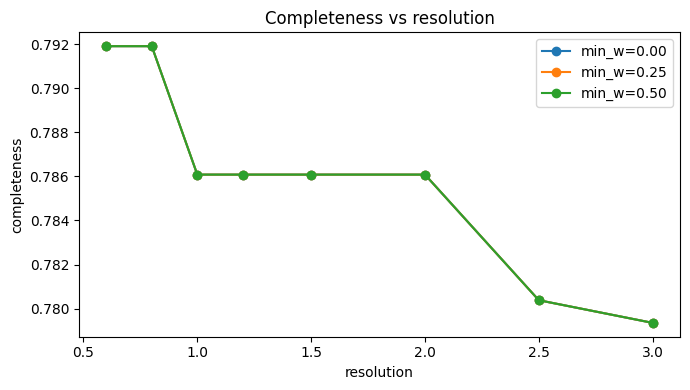

In [8]:
gt_primary_map, _, campaign_to_members_primary = rn.load_ground_truth_structures(PRIMARY_EVAL_GT)

shard_ids = shard_nodes_df["shard_id"].astype(str).tolist()
sweep_df, email_preds_by_key, info_by_key = s3.run_community_sweep(
    assignments_df=assignments_df,
    shard_ids=shard_ids,
    edges_df=edges_df,
    gt_label_map=gt_primary_map,
    method=COMMUNITY_METHOD,
    resolution_values=RESOLUTION_VALUES,
    min_edge_weight_values=MIN_EDGE_WEIGHT_VALUES,
    weight_col=COMMUNITY_WEIGHT_COL,
    seed=RANDOM_SEED,
)

# rank by completeness first (prototype focus), then v_measure, then homogeneity
sweep_df = sweep_df.sort_values(["completeness", "v_measure", "homogeneity"], ascending=[False, False, False]).reset_index(drop=True)
display(sweep_df)

plt.figure(figsize=(7, 4))
for w in sorted(sweep_df["min_edge_weight"].unique()):
    sub = sweep_df[sweep_df["min_edge_weight"] == w].sort_values("resolution")
    plt.plot(sub["resolution"], sub["completeness"], marker="o", label=f"min_w={w:.2f}")
plt.title("Completeness vs resolution")
plt.xlabel("resolution")
plt.ylabel("completeness")
plt.legend()
plt.tight_layout()
plt.show()

# 2b) Optional: manual multi-setting comparison across multiple Step-2 graphs
if STEP2_EXPERIMENTS:
    import json
    from collections import Counter

    def _load_step2_graph_config(step2_dir: Path) -> dict[str, object]:
        p = Path(step2_dir) / "semantic_shard_step2_graph_summary.json"
        if not p.exists():
            return {}
        d = json.loads(p.read_text(encoding="utf-8"))
        return d.get("graph_config_summary") or {}

    def _community_dominant_fraction(email_pred_df_: pd.DataFrame, gt_label_map_: dict[str, object], pred_comm_col: str = "pred_community"):
        gt = {str(k): v for k, v in gt_label_map_.items()}
        recs = []
        for comm, g in email_pred_df_.groupby(pred_comm_col, sort=False):
            eids = g["external_id"].astype(str).tolist()
            labs = [gt[e] for e in eids if e in gt]
            if not labs:
                dom_frac = np.nan
                dom_label = None
                cov = 0
            else:
                ct = Counter(labs)
                dom_label, dom_n = ct.most_common(1)[0]
                dom_frac = float(dom_n / max(1, len(labs)))
                cov = len(labs)
            recs.append({"pred_community": int(comm), "dominant_campaign_fraction": dom_frac, "coverage_gt": int(cov)})
        return pd.DataFrame(recs)

    def _over_merging_diagnostics(step2_edges_df: pd.DataFrame, email_pred_df_: pd.DataFrame, gt_label_map_: dict[str, object], *, top_evidence_k: int = 5):
        if step2_edges_df.empty:
            return None
        # Identify communities that are mixed across GT campaigns.
        comm_stats = _community_dominant_fraction(email_pred_df_, gt_label_map_)
        mixed_comms = comm_stats.dropna(subset=["dominant_campaign_fraction"])
        mixed_comms = mixed_comms[mixed_comms["dominant_campaign_fraction"] < 0.90]["pred_community"].astype(int).tolist()
        if not mixed_comms:
            return {"n_mixed_communities": 0, "top_evidence_by_mixed_edges": pd.DataFrame()}

        mixed_shards: set[str] = set()
        for comm in mixed_comms:
            mixed_shards.update(email_pred_df_.loc[email_pred_df_["pred_community"] == comm, "shard_id"].astype(str).tolist())

        edges_in = step2_edges_df[
            step2_edges_df["shard_a"].isin(mixed_shards) & step2_edges_df["shard_b"].isin(mixed_shards)
        ].copy()

        evidence_cols = [c for c in edges_in.columns if c.startswith("shared_") and c.endswith("_idf_sum")]
        if not evidence_cols or edges_in.empty:
            return {"n_mixed_communities": int(len(mixed_comms)), "top_evidence_by_mixed_edges": pd.DataFrame()}

        top_rows = []
        for c in evidence_cols:
            base = c[len("shared_") : -len("_idf_sum")]
            top_rows.append({"evidence": base, "mean_shared_idf_sum": float(edges_in[c].mean()), "frac_edges_with_any": float((edges_in[c] > 0).mean())})
        ev_df = pd.DataFrame(top_rows).sort_values("mean_shared_idf_sum", ascending=False).head(top_evidence_k)
        return {"n_mixed_communities": int(len(mixed_comms)), "top_evidence_by_mixed_edges": ev_df}

    rows = []
    diagnostics_by_key = {}
    for exp in STEP2_EXPERIMENTS:
        exp_key = exp.get("key") or "exp"
        step2_dir = Path(exp["step2_dir"]).expanduser().resolve()
        resolution = float(exp.get("resolution", RESOLUTION_VALUES[2] if len(RESOLUTION_VALUES) >= 3 else RESOLUTION_VALUES[0]))
        min_edge_weight = float(exp.get("min_edge_weight", MIN_EDGE_WEIGHT_VALUES[2] if len(MIN_EDGE_WEIGHT_VALUES) >= 3 else MIN_EDGE_WEIGHT_VALUES[0]))
        method = exp.get("method", COMMUNITY_METHOD)

        step2_nodes_df, step2_edges_df, _ = s3.load_step2_artifacts(step2_dir)
        shard_ids_ = step2_nodes_df["shard_id"].astype(str).tolist()

        graph_cfg = _load_step2_graph_config(step2_dir)
        enabled_cols = graph_cfg.get("scoring_infra_channels_cols") or graph_cfg.get("enabled_infra_channels_logical") or []
        enabled_channels_logical = [
            (c[:-4] if isinstance(c, str) and c.endswith("_set") else c)
            for c in enabled_cols
        ]
        semantic_min_cos = (graph_cfg.get("semantic_candidate") or {}).get("semantic_min_cos")

        wcol = str(exp.get("weight_col", "edge_weight"))
        shard_to_comm, info = s3.run_weighted_community_detection(
            shard_ids=shard_ids_,
            edges_df=step2_edges_df,
            method=method,
            resolution=resolution,
            min_edge_weight=min_edge_weight,
            weight_col=wcol,
            seed=RANDOM_SEED,
        )
        email_pred_df = s3.map_shards_to_email_predictions(assignments_df, shard_to_comm)
        m = s3.evaluate_external_metrics(email_pred_df, gt_primary_map)

        rows.append({
            "setting_key": exp_key,
            "enabled_channels_logical": ",".join(enabled_channels_logical) if isinstance(enabled_channels_logical, list) else enabled_channels_logical,
            "semantic_min_cos": semantic_min_cos,
            "resolution": resolution,
            "min_edge_weight": min_edge_weight,
            "homogeneity": m["homogeneity"],
            "completeness": m["completeness"],
            "v_measure": m["v_measure"],
            "n_edges_after_threshold": info["n_edges_after_threshold"],
            "n_communities": info["n_communities"],
        })

        # Over-merging diagnostics (mixed GT communities).
        diagnostics_by_key[exp_key] = _over_merging_diagnostics(step2_edges_df, email_pred_df, gt_primary_map)

        # Additional evidence diagnostics for high-weight edges (channel strength proxy).
        d = diagnostics_by_key.get(exp_key) or {}
        evidence_cols_all = [
            c
            for c in step2_edges_df.columns
            if c.startswith("shared_") and c.endswith("_idf_sum")
        ]
        top_edges = (
            step2_edges_df.sort_values("edge_weight", ascending=False).head(500)
            if not step2_edges_df.empty
            else step2_edges_df
        )
        top_weight_rows = []
        for c in evidence_cols_all:
            base = c[len("shared_") : -len("_idf_sum")]
            top_weight_rows.append(
                {
                    "evidence": base,
                    "mean_shared_idf_sum": float(top_edges[c].mean()) if not top_edges.empty else np.nan,
                    "frac_edges_with_any": float((top_edges[c] > 0).mean()) if not top_edges.empty else np.nan,
                }
            )
        d["top_evidence_by_top_weight_edges"] = (
            pd.DataFrame(top_weight_rows)
            .sort_values("mean_shared_idf_sum", ascending=False)
            .head(5)
        )
        diagnostics_by_key[exp_key] = d

    comparison_df = pd.DataFrame(rows)
    if not comparison_df.empty:
        comparison_df = comparison_df.sort_values(["v_measure"], ascending=[False, False]).reset_index(drop=True)
    display(comparison_df)
    (STEP3_OUT_DIR / "semantic_shard_step3_manual_comparison.csv").parent.mkdir(parents=True, exist_ok=True)
    comparison_df.to_csv(STEP3_OUT_DIR / "semantic_shard_step3_manual_comparison.csv", index=False)

    # Print compact evidence diagnostics for each setting.
    for k, d in diagnostics_by_key.items():
        if d is None:
            continue
        print(f"\n[Over-merging diagnostics] {k}")
        print("n_mixed_communities:", d.get("n_mixed_communities"))
        ev = d.get("top_evidence_by_mixed_edges")
        if ev is not None and isinstance(ev, pd.DataFrame) and not ev.empty:
            display(ev)
        tev = d.get("top_evidence_by_top_weight_edges")
        if tev is not None and isinstance(tev, pd.DataFrame) and not tev.empty:
            print("Top evidence (highest edge_weight edges):")
            display(tev)


## 3) Baseline comparison table (RAW + transformer)

Compare best Step-3 setting against existing baselines from clustering outputs.


In [5]:
baseline_df = s3.load_baseline_rows(
    raw_sweep_csv=RAW_SWEEP_CSV,
    transformer_sweep_csv=TRANSFORMER_SWEEP_CSV,
)

best_row = sweep_df.iloc[0].to_dict()
best_setting_key = str(best_row["setting_key"])
best_email_pred_df = email_preds_by_key[best_setting_key].copy()

best_proto_row = {
    "baseline": "ShardGraph_CommunityDetection_Best",
    "homogeneity": float(best_row.get("homogeneity", np.nan)),
    "completeness": float(best_row.get("completeness", np.nan)),
    "v_measure": float(best_row.get("v_measure", np.nan)),
    "n_clusters": float(best_row.get("n_communities", np.nan)),
    "coverage_ground_truth": float(best_row.get("coverage_gt", np.nan)),
    "model": best_row.get("method_used"),
    "embedding_mode": "step1_shards_plus_step2_weighted_graph",
}

comparison_df = pd.concat([baseline_df, pd.DataFrame([best_proto_row])], ignore_index=True)
display(comparison_df)


,baseline,homogeneity,completeness,v_measure,n_clusters,coverage_ground_truth,model,embedding_mode
0,RAW_graph_email_x,0.990121,0.676945,0.804116,169.0,0.868886,raw_email_embeddings,raw
1,Transformer_subject_body,0.996230,0.695644,0.819235,161.0,0.885190,transformer_text_embeddings,transformer_subject_body_raw
2,ShardGraph_CommunityDetection_Best,0.983941,0.857785,0.916542,1088.0,1.000000,louvain,step1_shards_plus_step2_weighted_graph


## 4) Map best shard communities back to emails

This produces the core prototype output:
- one row per email with shard id and final predicted community id.


In [6]:
best_shard_comm_df = (
    best_email_pred_df[["shard_id", "pred_community"]]
    .drop_duplicates()
    .sort_values(["pred_community", "shard_id"])
    .reset_index(drop=True)
)

display(best_email_pred_df.head(15))
print("n_email_predictions:", len(best_email_pred_df))
print("n_pred_communities:", best_shard_comm_df["pred_community"].nunique())


,external_id,cluster_label,is_noise,shard_id,pred_community
0,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,307,False,shard_307,84
1,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,307,False,shard_307,84
2,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,310,False,shard_310,0
3,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,228
4,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,215,False,shard_215,66
5,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,66
6,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,1
7,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,105
8,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,98,False,shard_98,228
9,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...,2


n_email_predictions: 4437
n_pred_communities: 860


## 5) Fragmentation before vs after (RAW vs prototype)

For each GT campaign, compare:
- number of clusters/communities touched
- dominant fraction
- fragmentation score

This highlights where the shard-graph method helps or hurts completeness behavior.


c:\Users\aar\Desktop\GNN-Campaign-Detection\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Top improvements (prototype better):


,campaign_id,campaign_size,num_pred_clusters_raw,dominant_fraction_raw,fragmentation_score_raw,num_pred_clusters_proto,dominant_fraction_proto,fragmentation_score_proto,delta_completeness_proxy,delta_fragmentation,delta_num_pred_clusters
0,25,2,0,0.000000,1.000000,1,1.000000,0.000000,1.000000,-1.000000,1
1,166,52,12,0.173077,0.826923,1,1.000000,0.000000,0.826923,-0.826923,-11
2,68,107,8,0.177570,0.822430,4,0.962617,0.037383,0.785047,-0.785047,-4
3,321,30,6,0.233333,0.766667,1,1.000000,0.000000,0.766667,-0.766667,-5
4,37,21,5,0.238095,0.761905,1,1.000000,0.000000,0.761905,-0.761905,-4
5,67,31,6,0.161290,0.838710,4,0.903226,0.096774,0.741935,-0.741935,-2
6,15,21,6,0.190476,0.809524,2,0.904762,0.095238,0.714286,-0.714286,-4
7,5,85,10,0.176471,0.823529,9,0.882353,0.117647,0.705882,-0.705882,-1
8,324,32,5,0.312500,0.687500,1,1.000000,0.000000,0.687500,-0.687500,-4
9,157,118,9,0.296610,0.703390,3,0.983051,0.016949,0.686441,-0.686441,-6


Top regressions (prototype worse):


,campaign_id,campaign_size,num_pred_clusters_raw,dominant_fraction_raw,fragmentation_score_raw,num_pred_clusters_proto,dominant_fraction_proto,fragmentation_score_proto,delta_completeness_proxy,delta_fragmentation,delta_num_pred_clusters
35,221,45,2,0.511111,0.488889,3,0.511111,0.488889,0.000000,0.000000,1
34,51,31,1,0.967742,0.032258,2,0.967742,0.032258,0.000000,0.000000,1
33,147,15,2,0.533333,0.466667,2,0.533333,0.466667,0.000000,0.000000,0
36,326,15,1,1.000000,0.000000,1,1.000000,0.000000,0.000000,0.000000,0
32,31,4,1,1.000000,0.000000,1,1.000000,0.000000,0.000000,0.000000,0
31,46,26,2,0.346154,0.653846,5,0.461538,0.538462,0.115385,-0.115385,3
30,178,69,10,0.188406,0.811594,5,0.304348,0.695652,0.115942,-0.115942,-5
29,74,6,2,0.833333,0.166667,1,1.000000,0.000000,0.166667,-0.166667,-1
28,197,49,5,0.265306,0.734694,3,0.448980,0.551020,0.183673,-0.183673,-2
27,41,5,2,0.800000,0.200000,1,1.000000,0.000000,0.200000,-0.200000,-1


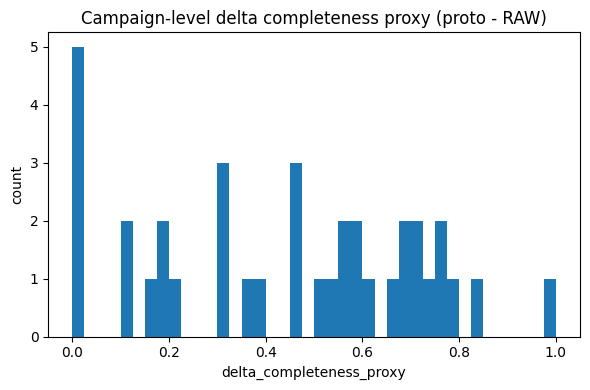

In [7]:
raw_pred_map, raw_rebuilt_metrics = s3.rebuild_raw_prediction_map(
    graph_pt=GRAPH_PT,
    meta_json=GRAPH_META,
    to_undirected=TO_UNDIRECTED,
    gt_label_map=gt_primary_map,
    raw_sweep_csv=RAW_SWEEP_CSV,
)
proto_pred_map = s3.proto_prediction_map_from_email_df(best_email_pred_df)

frag_cmp_df = s3.fragmentation_compare_table(
    campaign_to_members=campaign_to_members_primary,
    raw_pred_map=raw_pred_map,
    proto_pred_map=proto_pred_map,
)

print("Top improvements (prototype better):")
display(frag_cmp_df.head(20))
print("Top regressions (prototype worse):")
display(frag_cmp_df.sort_values("delta_completeness_proxy", ascending=True).head(20))

plt.figure(figsize=(6, 4))
plt.hist(frag_cmp_df["delta_completeness_proxy"].dropna(), bins=40)
plt.title("Campaign-level delta completeness proxy (proto - RAW)")
plt.xlabel("delta_completeness_proxy")
plt.ylabel("count")
plt.tight_layout()
plt.show()


## 6) Are RAW-fragmented campaigns being repaired?

Focus on campaigns that were split in RAW (`num_pred_clusters_raw > 1`) and classify outcomes.


,outcome,n_campaigns,fraction
0,improved_merge,27,0.818182
1,improved_other,4,0.121212
2,no_change,2,0.060606


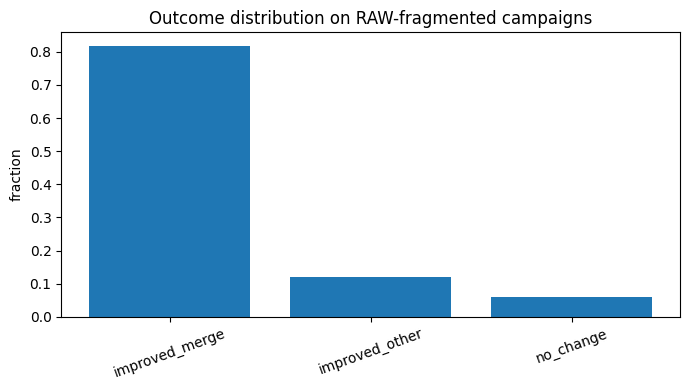

In [8]:
merge_outcomes_df = s3.split_campaign_merge_outcomes(frag_cmp_df)
display(merge_outcomes_df)

if not merge_outcomes_df.empty:
    plt.figure(figsize=(7, 4))
    plt.bar(merge_outcomes_df["outcome"], merge_outcomes_df["fraction"])
    plt.title("Outcome distribution on RAW-fragmented campaigns")
    plt.ylabel("fraction")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


## 7) Qualitative drill-down (campaign + merge evidence)

Pick a GT campaign and inspect:
- RAW vs prototype split behavior
- member email/shard assignments
- shard-pair edge evidence (semantic + infra + final weight)


In [9]:
# Set to a campaign id from frag_cmp_df to inspect.
DRILL_CAMPAIGN = frag_cmp_df.iloc[0]["campaign_id"] if not frag_cmp_df.empty else None

if DRILL_CAMPAIGN is None:
    print("No campaign available for drill-down.")
else:
    drill_members_df, drill_pairs_df = s3.campaign_drilldown_tables(
        campaign_id=DRILL_CAMPAIGN,
        campaign_to_members=campaign_to_members_primary,
        assignments_df=best_email_pred_df,
        raw_pred_map=raw_pred_map,
        proto_pred_map=proto_pred_map,
        edges_df=edges_df,
    )
    print("DRILL_CAMPAIGN:", DRILL_CAMPAIGN)
    print("Members / predictions:")
    display(drill_members_df.head(80))
    print("Involved shard-pair merge evidence:")
    display(drill_pairs_df.head(80))


DRILL_CAMPAIGN: 25.0
Members / predictions:


,external_id,cluster_label,is_noise,shard_id,pred_community,raw_pred,proto_pred
1817,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAA...,-1,True,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAg...,356,-1,356
1828,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAA...,-1,True,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAg...,356,-1,356


Involved shard-pair merge evidence:


,shard_a,shard_b,edge_weight,centroid_cosine,infra_score,temporal_score,shared_url_count,shared_sender_email_domain_count,shared_domain_count,shared_stem_count,shared_sender_count
29084,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAg...,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAg...,1.156846,0.999436,1.34911,1.0,0,1,0,0,1


## 8) Save Step-3 outputs

Artifacts saved:
- community parameter sweep results
- best setting summary JSON
- best email-level predictions
- best shard-to-community assignments


In [12]:
saved = s3.save_step3_outputs(
    output_dir=STEP3_OUT_DIR,
    sweep_df=sweep_df,
    best_setting_row={k: (float(v) if isinstance(v, (np.floating,)) else v) for k, v in best_row.items()},
    best_email_pred_df=best_email_pred_df,
    best_shard_comm_df=best_shard_comm_df,
)

for k, v in saved.items():
    print(f"{k}: {v}")


sweep_csv: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step3\semantic_shard_step3_sweep_results.csv
best_setting_json: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step3\semantic_shard_step3_best_setting.json
best_email_predictions_csv: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step3\semantic_shard_step3_email_predictions_best.csv
best_shard_communities_csv: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_step3\semantic_shard_step3_shard_communities_best.csv


## 9) Final Step-3 summary

This summary is the go/no-go checkpoint:
- completeness gain vs RAW
- homogeneity retention
- campaign types that improve or regress
- whether graph+community alone looks sufficient, or if Step 4 (GNN on shard graph) is warranted


In [13]:
raw_base = comparison_df[comparison_df["baseline"] == "RAW_graph_email_x"].head(1)
proto_base = comparison_df[comparison_df["baseline"] == "ShardGraph_CommunityDetection_Best"].head(1)

if not raw_base.empty and not proto_base.empty:
    raw_h = float(raw_base["homogeneity"].iloc[0])
    raw_c = float(raw_base["completeness"].iloc[0])
    proto_h = float(proto_base["homogeneity"].iloc[0])
    proto_c = float(proto_base["completeness"].iloc[0])
    print("Step-3 summary")
    print(f"- RAW: homogeneity={raw_h:.3f}, completeness={raw_c:.3f}")
    print(f"- Prototype best: homogeneity={proto_h:.3f}, completeness={proto_c:.3f}")
    print(f"- delta completeness: {proto_c - raw_c:+.3f}")
    print(f"- delta homogeneity: {proto_h - raw_h:+.3f}")

if not merge_outcomes_df.empty:
    improved = float(merge_outcomes_df.loc[merge_outcomes_df["outcome"].str.contains("improved"), "fraction"].sum())
    worse = float(merge_outcomes_df.loc[merge_outcomes_df["outcome"].str.contains("worse"), "fraction"].sum())
    print(f"- RAW-fragmented campaign outcomes: improved={improved:.3f}, worse={worse:.3f}")

if not raw_base.empty and not proto_base.empty:
    if (proto_c >= raw_c) and (proto_h >= raw_h - 0.03):
        print("\nInterpretation: two-stage shard-graph prototype looks promising enough to proceed; Step 4 (GNN) is optional/next optimization.")
    else:
        print("\nInterpretation: graph+community alone is not yet clearly better; tune graph/weights/community settings before moving to Step 4.")


Step-3 summary
- RAW: homogeneity=0.990, completeness=0.677
- Prototype best: homogeneity=0.953, completeness=0.883
- delta completeness: +0.206
- delta homogeneity: -0.037
- RAW-fragmented campaign outcomes: improved=0.939, worse=0.000

Interpretation: graph+community alone is not yet clearly better; tune graph/weights/community settings before moving to Step 4.
